# How to use `pywikibot`

Load library, and check that your username was set (to create a unique user agent for API limits). Read from `user-config.py` in the same folder as the notebook if available, created by `pwb generate_user_files`

## Setup

In [27]:
import pywikibot
import pandas as pd
pywikibot.config.usernames

defaultdict(dict, {'wikipedia': {'en': 'Gedankenstuecke'}, 'wikidata': {}})

If you see a username for your language edition for Wikipedia you're all set. Now we can start getting all pages for a given category.

## Getting all Kenyan politician pages (based on category)

Using `recurse=True` lets us also get files present in sub-categories if present. For the demo we use `Category:Kenyan_politicians` as the category of interest:

In [3]:
site = pywikibot.Site('en', 'wikipedia') # select the wikimedia project we want to interact with

politician_pages = [] # to store page names and handles after iterating over category
category = pywikibot.Category(site, "Kenyan_politicians") # select category

for i in category.articles(recurse=True):
    politician_pages.append(i)

In [4]:
print("There are {} pages in the 'Kenyan politicians' category".format(len(politician_pages)))

There are 933 pages in the 'Kenyan politicians' category


## Getting a single page

Let's use a single page as an example to explore what else we can easily get from the API.

In [5]:
page = politician_pages[0]
page.title()

'Abdilatif Abdalla'

We can now access the latest version of the article:

In [6]:
page.text[:2000]

'{{short description|Kenyan writer and political activist}}\n{{Use dmy dates|date=April 2022}}\n\'\'\'Abdilatif Abdalla\'\'\' (born 1946 in [[Mombasa]]) is a Kenyan writer and political activist. He was imprisoned for his support of the [[Kenya People\'s Union]], and began writing poetry in [[solitary confinement]]. A collection of poems from this time were published as a book titled \'\'Sauti ya Dhiki\'\'{{efn|"Voice of Agony"}} (1973), which was awarded the [[Jomo Kenyatta Prize for Literature]].\n\n==Early life==\nAbdilatif Abdalla was born in [[Mombasa]], [[Kenya]], in 1946, where he was brought up by his grandfather Ahmad Basheikh bin Hussein. Abdalla attended school in [[Faza]], before undertaking further studies at the British Tutorial College. He began his political involvement after working for the Mombasa City Council as an assistant [[accountant]], writing the pamphlet \'\'Kenya Twendapi?\'\' (Eng: \'\'Kenya, Where Are We Headed\'\') in support of the [[Kenya People\'s Union

## Exploring categories a page belongs to

We can now see if or to which other category pages this page belongs, e.g. if we'd use this to expand our serach

In [41]:
for c in page.categories():
    print(c)

[[en:Category:1946 births]]
[[en:Category:Academic staff of Leipzig University]]
[[en:Category:Academic staff of the University of Dar es Salaam]]
[[en:Category:Articles with short description]]
[[en:Category:BBC people]]
[[en:Category:Kenyan male writers]]
[[en:Category:Kenyan politicians]]
[[en:Category:Kenyan writers]]
[[en:Category:Living people]]
[[en:Category:People associated with SOAS University of London]]
[[en:Category:People from Mombasa]]
[[en:Category:Short description is different from Wikidata]]
[[en:Category:Swahili-language writers]]
[[en:Category:Use dmy dates from April 2022]]


## Authorship

To check how authorship for the current text status distributes across users we can do the following. Each tupel of the form `(1234, 50.0)` gives the authorship in character count (`1234`) and percentage of the article `(50.0`)

In [36]:
page.authorship()

{'Miyagawa': (2195, 52.0),
 'Gaudio': (759, 18.0),
 '2A02:8070:D1AC:E500:D480:B9B7:2A33:B6F6': (295, 7.0),
 'Vysotsky': (253, 6.0),
 'IOHANNVSVERVS': (168, 4.0)}

Now we can check how many revisions there were:

In [25]:
page.revision_count()

46

We can also explore the different revisions, when they were made, by whom and the edit-comment that was left

In [37]:
for i in page.revisions():
    print("{} edited the article on {} with this edit comment: {}".format(i['user'], i['timestamp'], i['comment']))

Almaddy2022 edited the article on 2025-04-14T10:08:57Z with this edit comment: 
Almaddy2022 edited the article on 2025-04-06T12:24:59Z with this edit comment: /* Political imprisonment and writing */ I have added links of Kimati Prison and Shimo la Tewa
Inter&anthro edited the article on 2024-08-23T20:59:25Z with this edit comment: mentioned and sourced in the article
IOHANNVSVERVS edited the article on 2024-03-27T06:08:59Z with this edit comment: /* Political imprisonment and writing */ce
IOHANNVSVERVS edited the article on 2024-03-27T06:08:39Z with this edit comment: /* References */
IOHANNVSVERVS edited the article on 2024-03-27T06:07:52Z with this edit comment: /* Political imprisonment and writing */Voices of Agony
IOHANNVSVERVS edited the article on 2024-03-27T06:06:57Z with this edit comment: /* Political imprisonment and writing */correct date
IOHANNVSVERVS edited the article on 2024-03-27T06:05:52Z with this edit comment: copyedit lead
IOHANNVSVERVS edited the article on 2024-

Looking carefully, you'll see that there are authors named which aren't listed as the current `authorship` marks. To see all contributors, even if no text of them is in the latest version, we can use:

In [42]:
page.contributors()

Counter({'IOHANNVSVERVS': 6,
         'Miyagawa': 3,
         'Vysotsky': 3,
         'Almaddy2022': 2,
         'JJMC89 bot III': 2,
         '2A02:8070:D1AC:E500:D480:B9B7:2A33:B6F6': 2,
         'InternetArchiveBot': 2,
         'KasparBot': 2,
         'KConWiki': 2,
         'ZéroBot': 2,
         'Inter&anthro': 1,
         '96.106.43.35': 1,
         '196.202.223.224': 1,
         'BrownHairedGirl': 1,
         'SdkbBot': 1,
         'Citation bot': 1,
         'Simeon': 1,
         '75.188.45.156': 1,
         'Jevansen': 1,
         'Ser Amantio di Nicolao': 1,
         '79.178.31.23': 1,
         'Materialscientist': 1,
         'Abdiladif33': 1,
         'GoodDay': 1,
         'Addbot': 1,
         'Dsp13': 1,
         'SwisterTwister': 1,
         'Bgwhite': 1,
         'Hmains': 1,
         'Gaudio': 1})

## Exploring contributors

Let's now investigate a bit more details about those users:

1. how much have they edited in Wikipedia?
2. are they a bot? and how many of the overall editors are bots?
3. if they declare: what is their gender?

In [60]:
bot_editors = 0 # for counting bots

for i in page.contributors():
    user = pywikibot.User(site, i) # get user object to manipulate
    user_groups = user.groups()
    print("{} made {} edits, declared their gender as {} and is in these user groups {}".format(i, 
                                                                                                user.editCount(),
                                                                                                user.gender(),
                                                                                                user_groups))
    if "bot" in user_groups:
        bot_editors += 1

print("In total {} of {} editors are bots ({} %)".format(bot_editors,
                                                       len(page.contributors()),
                                                       bot_editors/len(page.contributors())
                                                      ))
    

Almaddy2022 made 883 edits, declared their gender as unknown and is in these user groups ['extendedconfirmed', '*', 'user', 'autoconfirmed']
Inter&anthro made 89857 edits, declared their gender as unknown and is in these user groups ['extendedconfirmed', '*', 'user', 'autoconfirmed']
IOHANNVSVERVS made 10862 edits, declared their gender as unknown and is in these user groups ['extendedconfirmed', '*', 'user', 'autoconfirmed']
96.106.43.35 made 0 edits, declared their gender as unknown and is in these user groups []
196.202.223.224 made 0 edits, declared their gender as unknown and is in these user groups []
JJMC89 bot III made 5653001 edits, declared their gender as unknown and is in these user groups ['bot', 'sysop', '*', 'user', 'autoconfirmed']
BrownHairedGirl made 2942733 edits, declared their gender as female and is in these user groups ['autoreviewer', 'extendedconfirmed', 'filemover', 'reviewer', 'rollbacker', '*', 'user', 'autoconfirmed']
SdkbBot made 370790 edits, declared the

If we want, we can also explore the other content that those editors have touched. Using a single editor as an example:

In [62]:
user = pywikibot.User(site, "Almaddy2022")

for page in user.contributions(total=50):
    print(page)

(Page('Lamu Fort Library'), 1332190871, Timestamp(2026, 1, 10, 12, 6, 14), 'I have added a citation')
(Page('Lamu Fort Library'), 1332190768, Timestamp(2026, 1, 10, 12, 4, 47), '/* Archive section */ I have added a citation for ustadh Mau')
(Page('Lamu Fort Library'), 1311935664, Timestamp(2025, 9, 17, 18, 50, 39), '/* Friends of the Library */ I have added a link of the friends of the library')
(Page('Lamu Fort Library'), 1311935285, Timestamp(2025, 9, 17, 18, 47, 52), '/* Friends of the Library */ I have added a friend of library')
(Page('Mamie Buazo'), 1298753712, Timestamp(2025, 7, 4, 13, 3, 21), 'I have added a reference on the content I have added on the short description space about her life time')
(Page('Mamie Buazo'), 1298753164, Timestamp(2025, 7, 4, 12, 59, 20), 'I have added contents on mamie short description')
(Page('Mamie Buazo'), 1298751050, Timestamp(2025, 7, 4, 12, 42, 44), 'I have added her childhood life of Mamie')
(Page('Mamie Buazo'), 1298750577, Timestamp(2025, 7

## Aggregating the data

Now let's start making a large data frame that contains all the edits for all the pages in this category. For now let's start by making a data frame for a single page - and then plot the contributions of users to it - both measured by number of submitted revisions and the total of added/removed characters.

We start with a random page: 

In [11]:
p = politician_pages[1]

Now we:

1. get all the revisions into a dataframe
2. then add the page title
3. calculate the size difference of the article, to evaluate how much text each edit added/removed

In [45]:
df = pd.DataFrame(p.revisions(content=True))
df['page_title'] = p.title() # add title which is missing from revisions
df['size_difference'] = df['size'] - df['size'].shift(periods=-1, fill_value=0) # add the size difference between each revision / previous state 



### Plotting the number of edits per editor

<Axes: xlabel='user'>

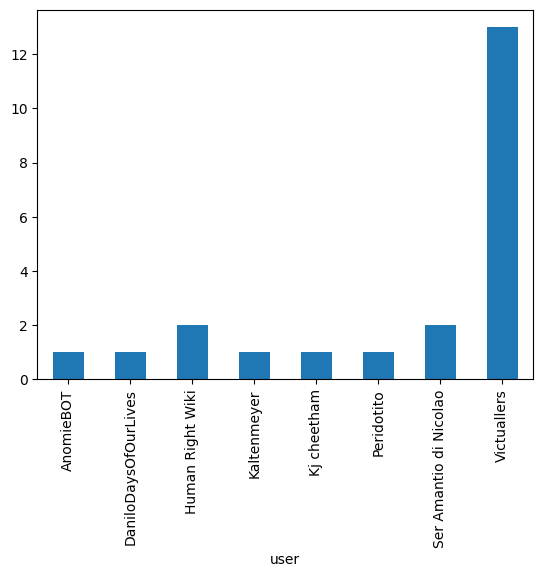

In [56]:
df.groupby(["user"]).count()['userid'].plot(kind='bar')

### Plotting the overall size change made by the editor

Note: A user could show up as "zero" edits, if they added and removed text of the same volume 

<Axes: xlabel='user'>

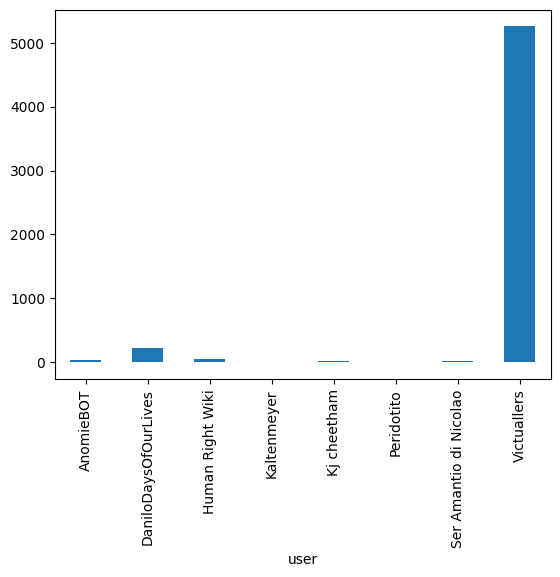

In [66]:
df.groupby('user')['size_difference'].sum().plot(kind='bar')

## Creating a `DataFrame` for all pages

Now that we got a working code to create a `DataFrame` over all revisions of a single page, let's zoom one more step out - and create it for all pages in our category:

In [86]:
df_politicians = pd.DataFrame()

for p in politician_pages:
    df = pd.DataFrame(p.revisions(content=True))
    df['page_title'] = p.title() # add title which is missing from revisions
    df['size_difference'] = df['size'] - df['size'].shift(periods=-1, fill_value=0) # add the size difference between each revision / previous state 
    if not df_politicians.empty:
        df_politicians = pd.concat([df_politicians, df])
    else:
        df_politicians = df

df_politicians.head()

,revid,parentid,minor,user,userid,timestamp,size,sha1,roles,slots,...,anon,userhidden,commenthidden,text,contentmodel,page_title,size_difference,temp,sha1hidden,suppressed
0,1285549690,1284245409,True,Almaddy2022,44620763.0,2025-04-14 10:08:57,4224,dac6097a46b4f8553538a7cd72f8e21144a98f25,[main],"{'main': {'contentmodel': 'wikitext', 'content...",...,False,False,False,{{short description|Kenyan writer and politica...,wikitext,Abdilatif Abdalla,8,NaN,NaN,NaN
1,1284245409,1241910337,False,Almaddy2022,44620763.0,2025-04-06 12:24:59,4216,9702f3020b6af39bfe3d4c665ddff5caa65b9b51,[main],"{'main': {'contentmodel': 'wikitext', 'content...",...,False,False,False,{{short description|Kenyan writer and politica...,wikitext,Abdilatif Abdalla,93,NaN,NaN,NaN
2,1241910337,1215802812,True,Inter&anthro,18180119.0,2024-08-23 20:59:25,4123,3855f560b43074cb4ddf410042636935866d6e54,[main],"{'main': {'contentmodel': 'wikitext', 'content...",...,False,False,False,{{short description|Kenyan writer and politica...,wikitext,Abdilatif Abdalla,38,NaN,NaN,NaN
3,1215802812,1215802775,False,IOHANNVSVERVS,24759391.0,2024-03-27 06:08:59,4085,edde49d1d4e95abcdd491f4e142fdd2f3fed23eb,[main],"{'main': {'contentmodel': 'wikitext', 'content...",...,False,False,False,{{short description|Kenyan writer and politica...,wikitext,Abdilatif Abdalla,-1,NaN,NaN,NaN
4,1215802775,1215802684,False,IOHANNVSVERVS,24759391.0,2024-03-27 06:08:39,4086,6e4050681632db2525ccc51e26e2cf99ab2a9a42,[main],"{'main': {'contentmodel': 'wikitext', 'content...",...,False,False,False,{{short description|Kenyan writer and politica...,wikitext,Abdilatif Abdalla,13,NaN,NaN,NaN


<Axes: xlabel='page_title'>

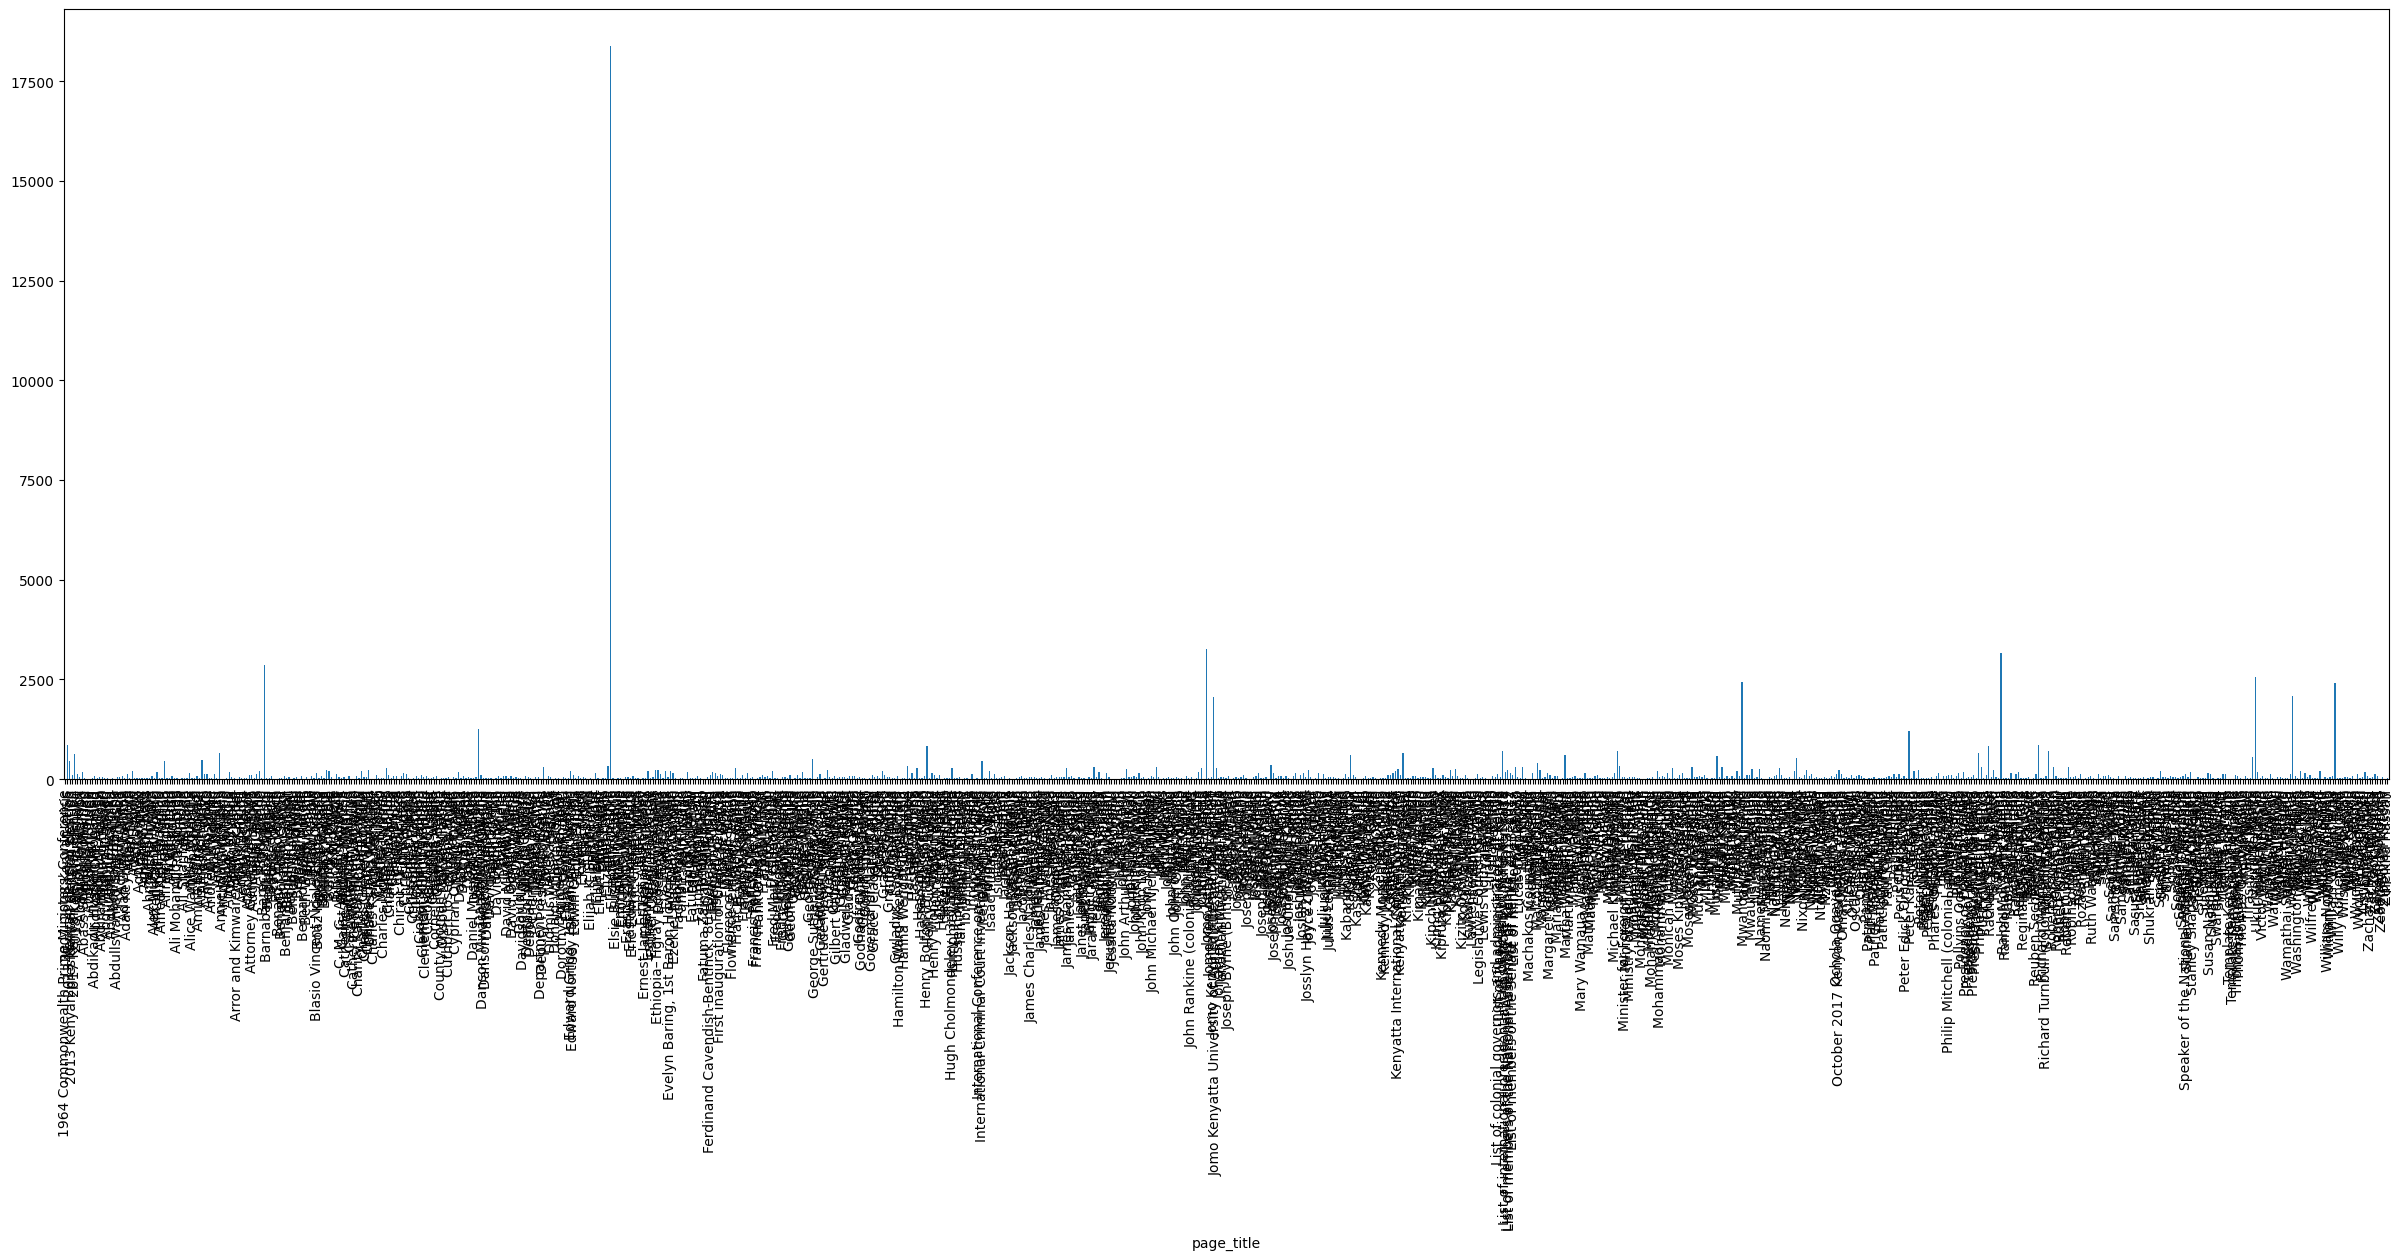

In [87]:
df_politicians.groupby(["page_title"]).count()['user'].plot(kind='bar',figsize=(30,10))

Now we can save this data frame with all of those details:

In [88]:
df_politicians.to_csv('pages_category_kenyian_politicians.csv')